In [170]:
import warnings
warnings.filterwarnings("ignore")

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
sns.set_theme(style = "darkgrid")

In [144]:
pd.set_option('display.max_columns', None)

## Problem Statement

* ***XYZ*** has provided a dataset describing customer behavior and purchasing patterns. 
The company wants to identify patterns among different groups of customers in order 
to improve its services and overall business strategy.

* The goal of this project is to analyze customer purchasing behavior and use clustering 
algorithms to group customers into distinct segments. These segments can help the 
business better understand its customers and develop targeted marketing strategies.

In [79]:
df = pd.read_csv("marketing_campaign.csv", sep='\t')

In [80]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [81]:
df.shape

(2240, 29)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## **Data Understanding:**

- **People**

    - **ID:** Customer's unique identifier
    - **Year_Birth:** Customer's birth year
    - **Education:** Customer's education level
    - **Marital_Status:** Customer's marital status
    - **Income:** Customer's yearly household income
    - **Kidhome:** Number of children in customer's household
    - **Teenhome:** Number of teenagers in customer's household
    - **Dt_Customer:** Date of customer's enrollment with the company
    - **Recency:** Number of days since customer's last purchase
    - **Complain:** 1 if the customer complained in the last 2 years, 0 otherwise

- **Products**

    - **MntWines:** Amount spent on wine in last 2 years
    - **MntFruits:** Amount spent on fruits in last 2 years
    - **MntMeatProducts:** Amount spent on meat in last 2 years
    - **MntFishProducts:** Amount spent on fish in last 2 years
    - **MntSweetProducts:** Amount spent on sweets in last 2 years
    - **MntGoldProds:** Amount spent on gold in last 2 years

- **Promotion**

    - **NumDealsPurchases:** Number of purchases made with a discount
    - **AcceptedCmp1:** 1 if customer accepted the offer in the 1st campaign, 0 otherwise
    - **AcceptedCmp2:** 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
    - **AcceptedCmp3:** 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
    - **AcceptedCmp4:** 1 if customer accepted the offer in the 4th campaign, 0 otherwise
    - **AcceptedCmp5:** 1 if customer accepted the offer in the 5th campaign, 0 otherwise
    - **Response:** 1 if customer accepted the offer in the last campaign, 0 otherwise

- **Place**

    - **NumWebPurchases:** Number of purchases made through the company’s website
    - **NumCatalogPurchases:** Number of purchases made using a catalogue
    - **NumStorePurchases:** Number of purchases made directly in stores
    - **NumWebVisitsMonth:** Number of visits to company’s website in the last month

Numerical and Catagorical columns separation

In [83]:
numerical_col = []
catagorical_col = []

for i in df.columns:
    if df[i].dtype == "object" :
        catagorical_col.append(i)
    else:
        numerical_col.append(i);


In [85]:
print(f"Total number of numerical columns is: {len(numerical_col)}. And those are: {numerical_col}")
print(f"Total number of catagorical columns is: {len(catagorical_col)}. And those are: {catagorical_col}")

Total number of numerical columns is: 26. And those are: ['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']
Total number of catagorical columns is: 3. And those are: ['Education', 'Marital_Status', 'Dt_Customer']


The dataset contains ***26*** **Numerical Columns** and ***3*** **Catagorical Columns**

## **Univariate Analysis:**

**Numerical Features:**

In [86]:
print(numerical_col)

['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


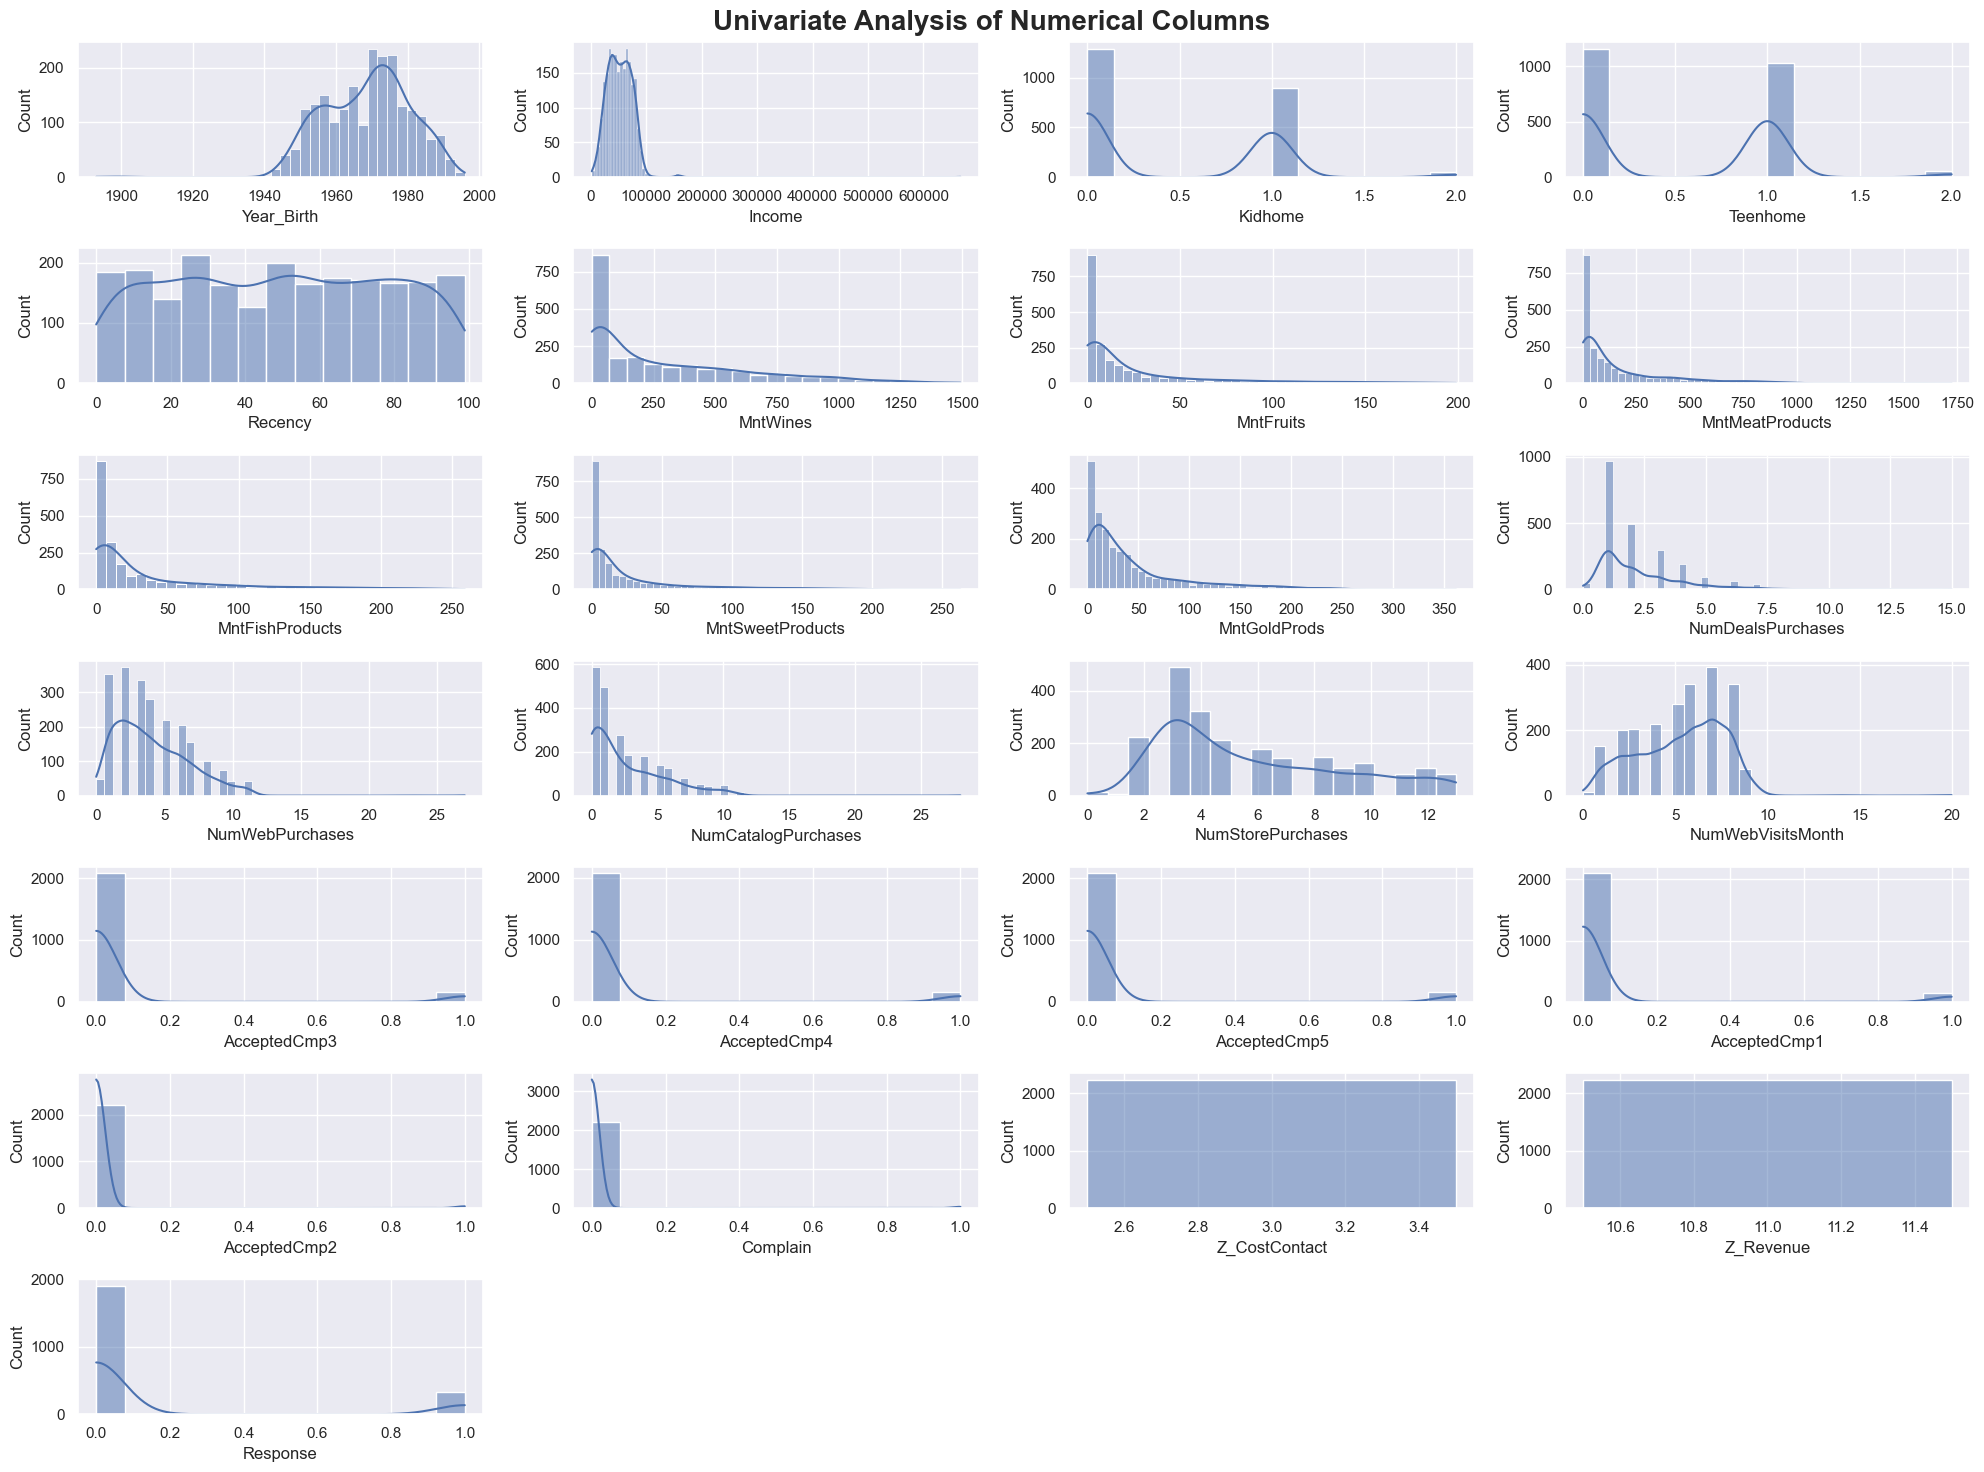

In [87]:
plt.figure(figsize=(20,15))
plt.suptitle("Univariate Analysis of Numerical Columns", fontsize = 20, fontweight = 'bold')

for i in range(1, len(numerical_col)):
    plt.subplot(7,4, i)
    plt.xlabel(numerical_col[i])
    sns.histplot(x = df[numerical_col[i]], kde = True)
    plt.tight_layout()

plt.show()


**Observations:**

1. **Year_Birth**: Left-skewed; Most of the data are in range 1940-2000; Has Outliers
2. **Income**: Rigt skewed; Has Outliers
3. **Kidhome**: Seems to be constant (0, 1) and sometimes 2
4. **Teenhome**: Same
5. **Recency**: Normal Distribution
6. **Mntwines, MntMeatProducts** : Right skewed and lies in between 0-1000; Has Outliers
7. **MntFruits, MntFishProducts, MntSweetProducts, MntGoldProds**: Right Skewed and lies in between 0-150; Has Outliers
8. **NumDealsPurchases, NumWebPurchases, NumCatalogPurchases, NumStorePurchases**: Right skwewd and range 0-10; Has Outliers
9. **NumWebVisitsMonth** : Left Skewed; Most data in 0-10; Has Outliers
10. **AcceptedCmp3, AcceptedCmp4, AcceptedCmp5, AcceptedCmp1, AcceptedCmp2, Complain, Response** : 0 is maximum of the time
11. **Z_CostContact, Z_Revenue**: Constant Values

**Catagorical Features:**

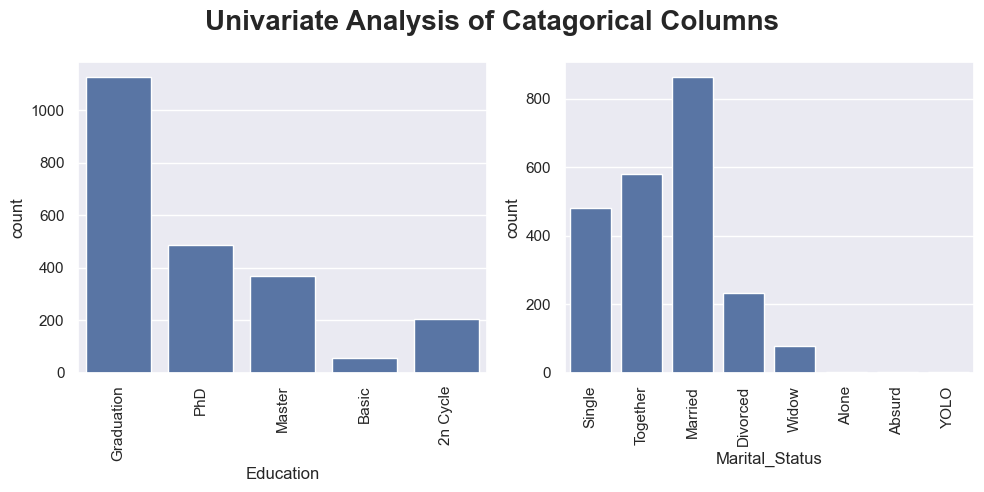

In [88]:
plt.figure(figsize=(10,5))
plt.suptitle("Univariate Analysis of Catagorical Columns", fontsize = 20, fontweight = 'bold')

for i in range(0,len(catagorical_col)-1):
    plt.subplot(1,2, i+1)
    plt.xlabel(catagorical_col[i])
    plt.xticks(rotation  = 90)
    sns.countplot(x = df[catagorical_col[i]])
    plt.tight_layout()

plt.show()


**Observatiions:**

* Most of the Customers are **Graduates** and Least are **Basic**
* Most of the Customers are **Married** and very less people are **Alone, YOLO and Absurd**

**Exploring the ***Dt_Customers*** Feature:**

In [89]:
df1 = df.copy()
df1["Dt_Customer"] = pd.to_datetime(df1["Dt_Customer"], format = "%d-%m-%Y")

In [90]:
df1["Customer_Year"] = df1["Dt_Customer"].dt.year

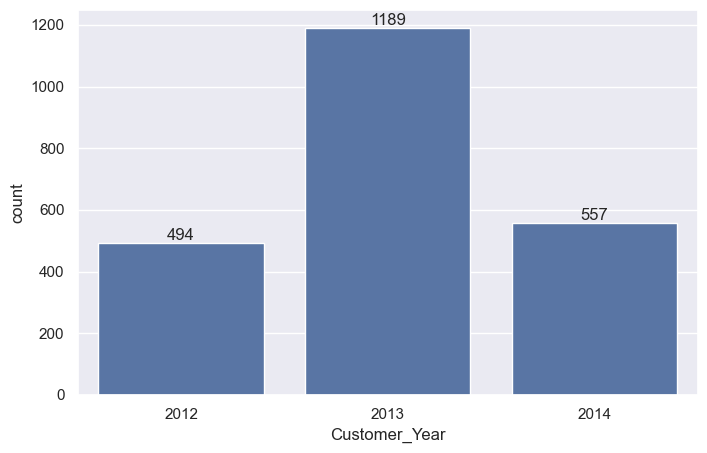

In [91]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x="Customer_Year", data=df1)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

The customers engagement : 2013 > 2014 > 2012

In [92]:
print(df1["Dt_Customer"].min())
print(df1["Dt_Customer"].max())

2012-07-30 00:00:00
2014-06-29 00:00:00


As Only 6 months of 2014 has been stored, the trend of 2014 is almost equivalent to 2013

## **Multivariate Analysis:**

<Axes: >

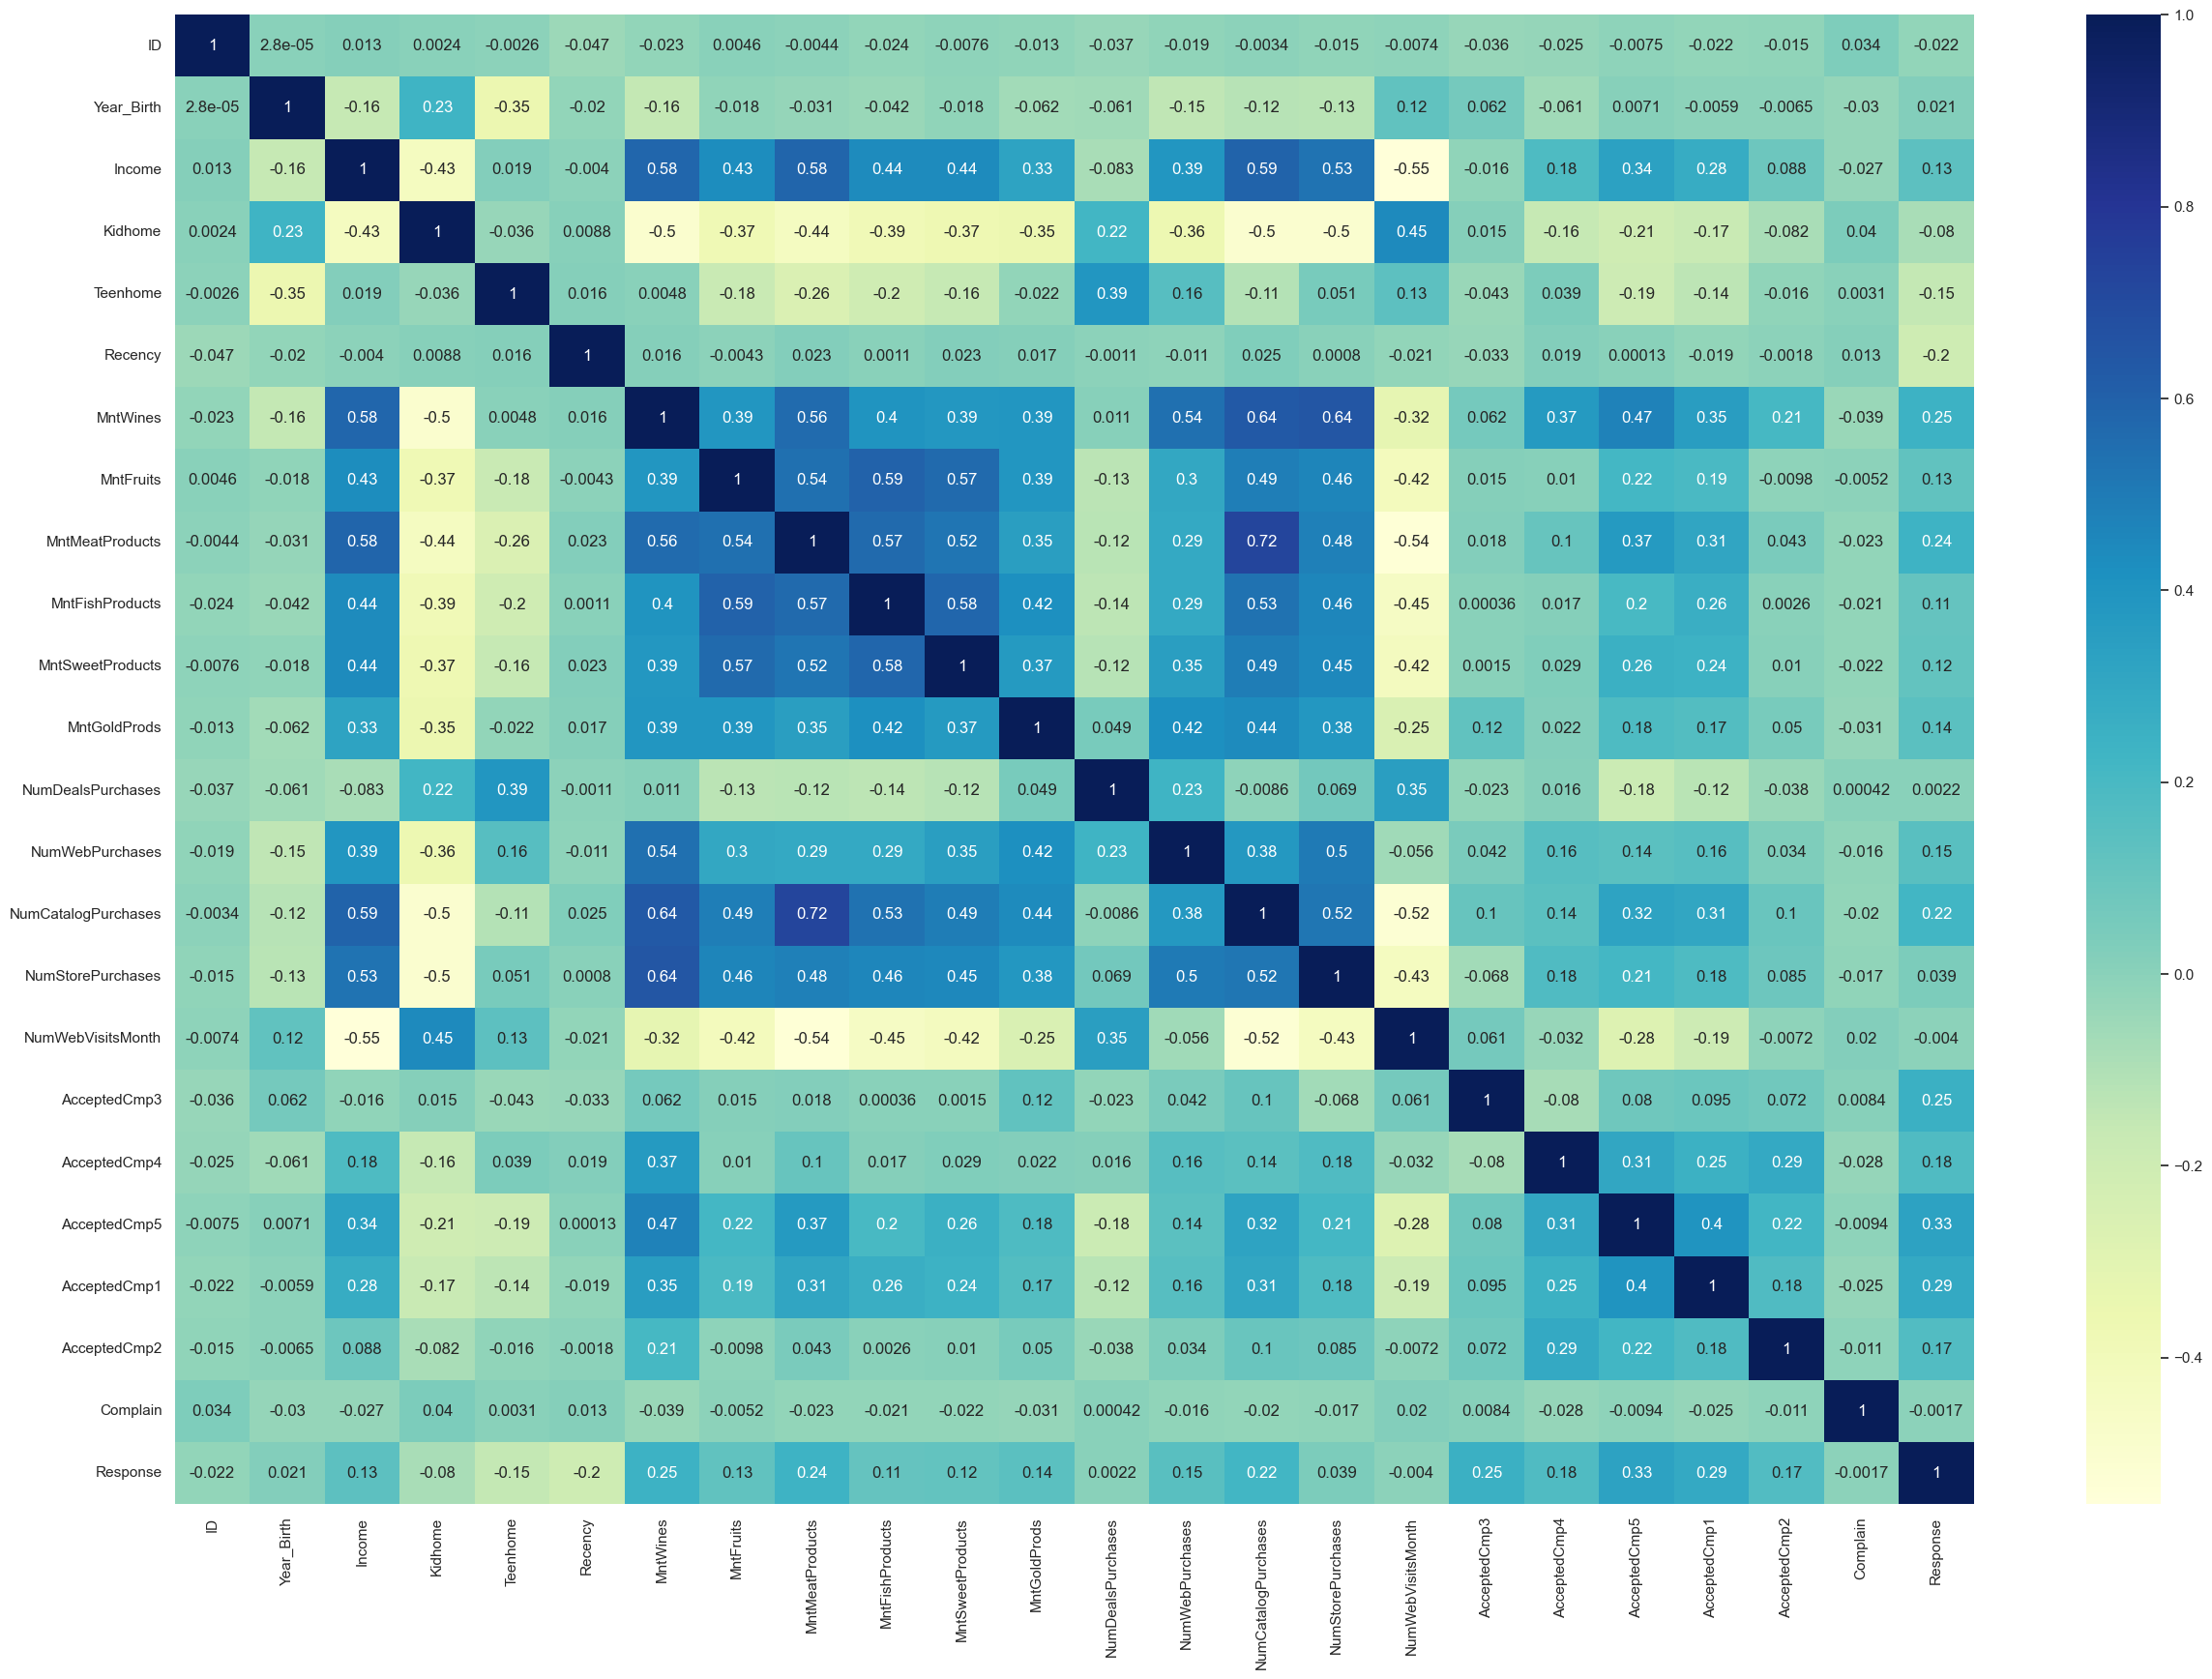

In [93]:
plt.figure(figsize =(30,20))
num = [i for i in numerical_col if i != 'Z_CostContact' and i != 'Z_Revenue']
sns.heatmap(df[num].corr(), annot = True, cmap="YlGnBu")

## **Data Cleaning:**

In [94]:
df.duplicated().sum()
## No duplicates

np.int64(0)

## Outlier Detection:

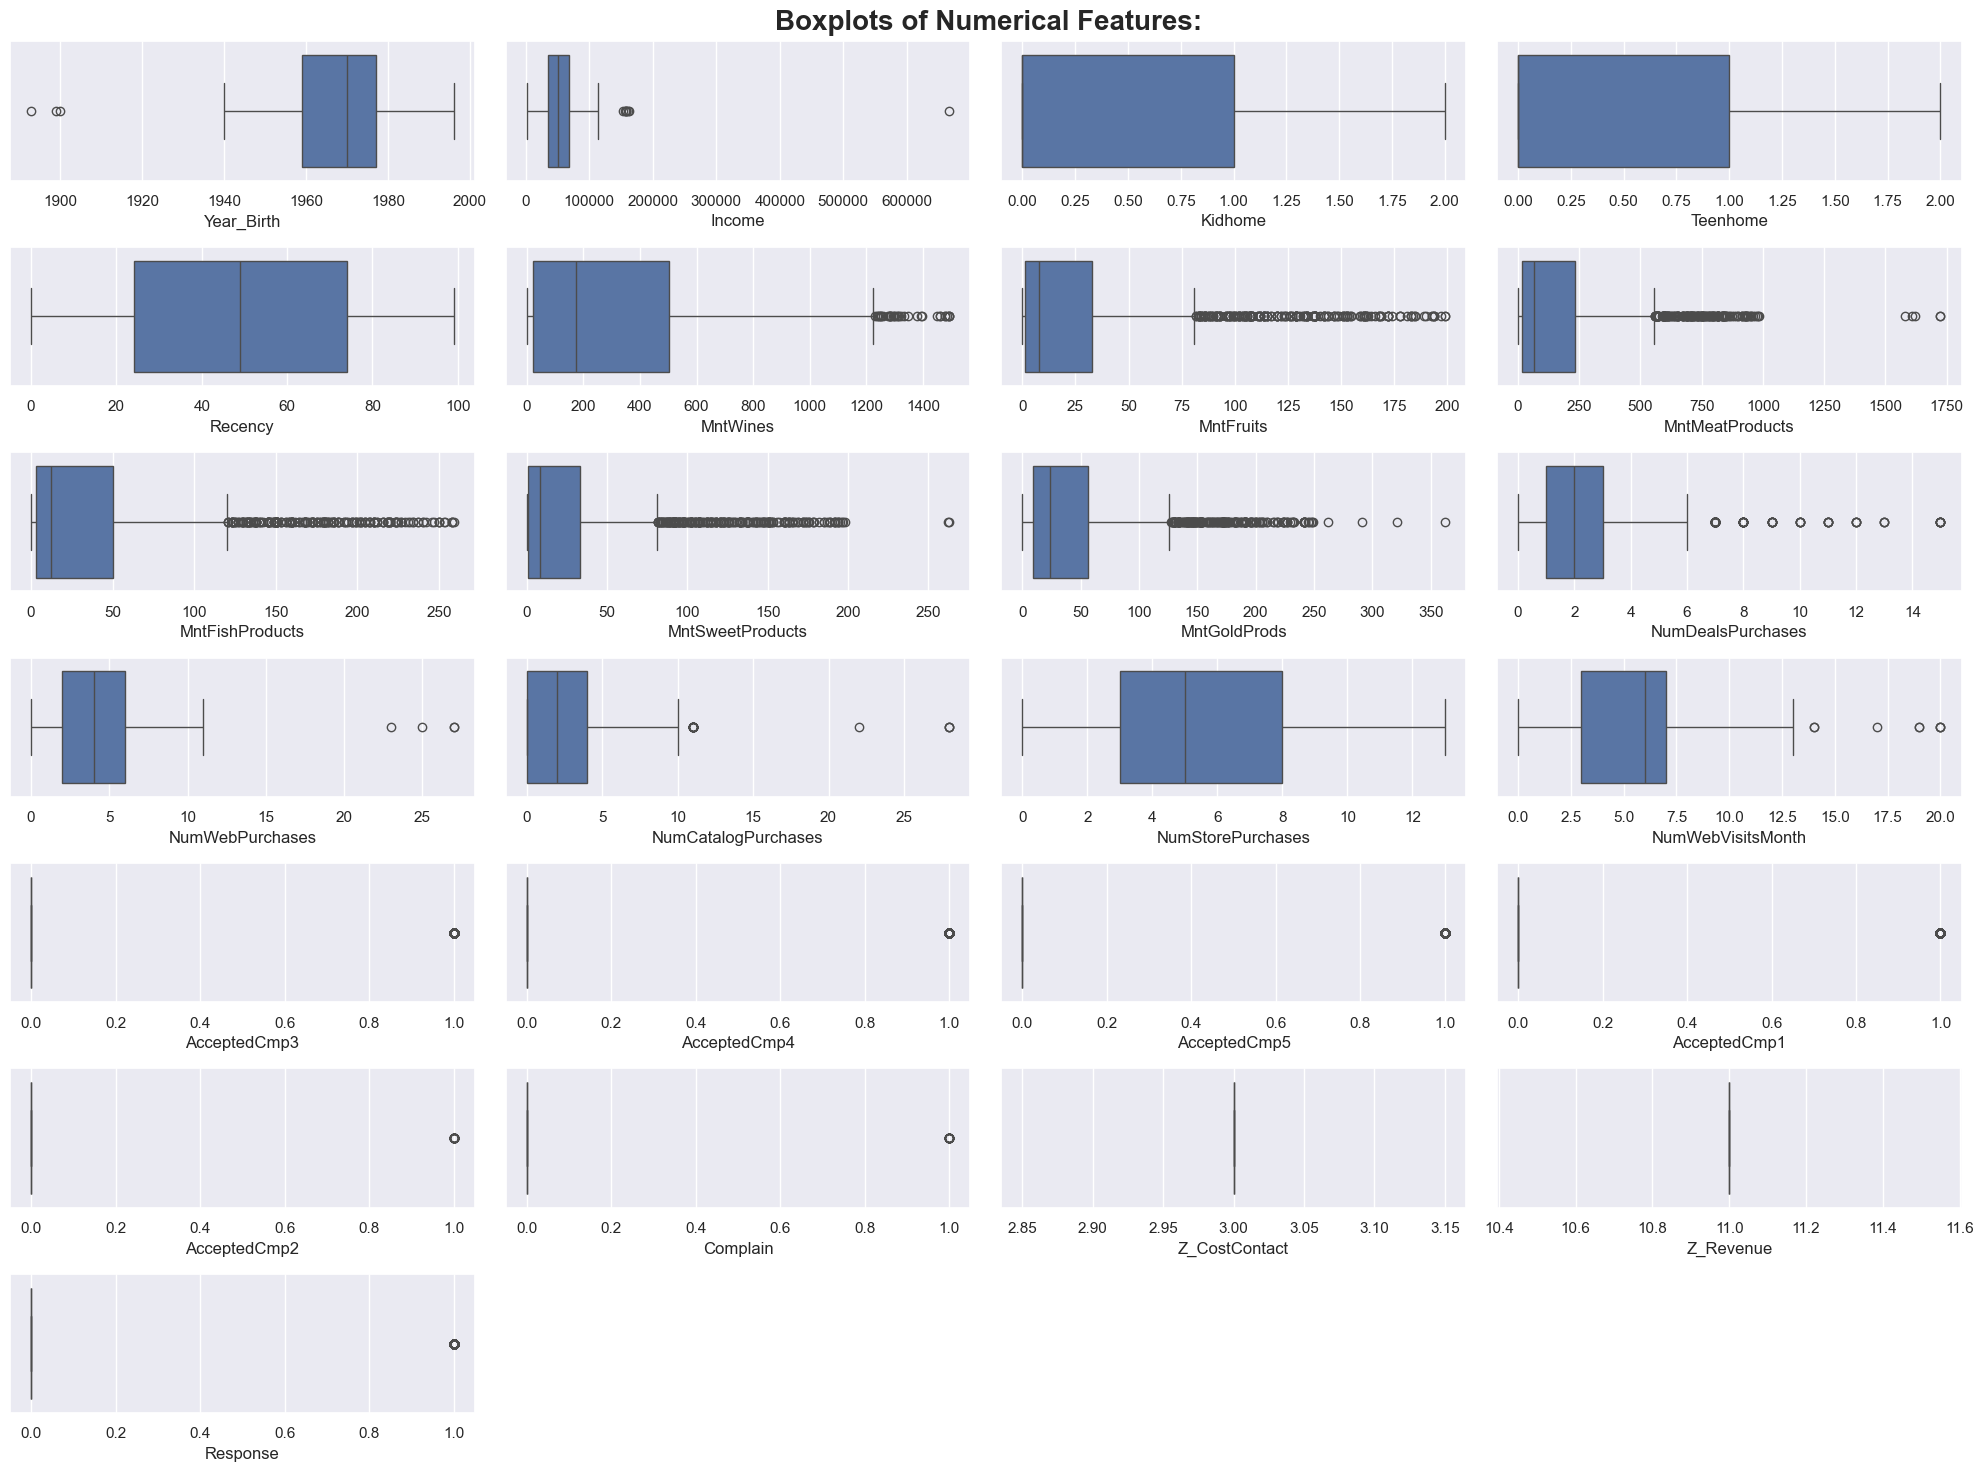

In [95]:
plt.figure(figsize=(20,15))
plt.suptitle("Boxplots of Numerical Features: ", fontsize = 20, fontweight = 'bold')

for i in range(1, len(numerical_col)):
    plt.subplot(7,4, i)
    plt.xlabel(numerical_col[i])
    sns.boxplot(x = df[numerical_col[i]])
    plt.tight_layout()

plt.show()

**Outlier Capping**

In [96]:
def outlier_cap(col_name, data):
    iqr = data[col_name].quantile(0.75) - data[col_name].quantile(0.25)
    lower_limit = data[col_name].quantile(0.25) - 1.5*iqr
    upper_limit = data[col_name].quantile(0.75) + 1.5*iqr
    for i in range(0, len(data[col_name])):
        if data.loc[i, col_name] > upper_limit:
            data.loc[i, col_name] = upper_limit
        elif data.loc[i, col_name] < lower_limit:
            data.loc[i, col_name] = lower_limit

    ## the for loop can be replaced with clipping data[col_name] = data[col_name].clip(lower = lower_limit, upper = upper_limit)

    return data[col_name]



In [97]:
print(numerical_col)

['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [98]:
nums = ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
for i in nums:
    df[i] = outlier_cap(i, df)

C:\Users\Sukalpo Deb Nath\AppData\Local\Temp\ipykernel_28328\2142064906.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '120.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[i, col_name] = upper_limit
C:\Users\Sukalpo Deb Nath\AppData\Local\Temp\ipykernel_28328\2142064906.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '126.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[i, col_name] = upper_limit


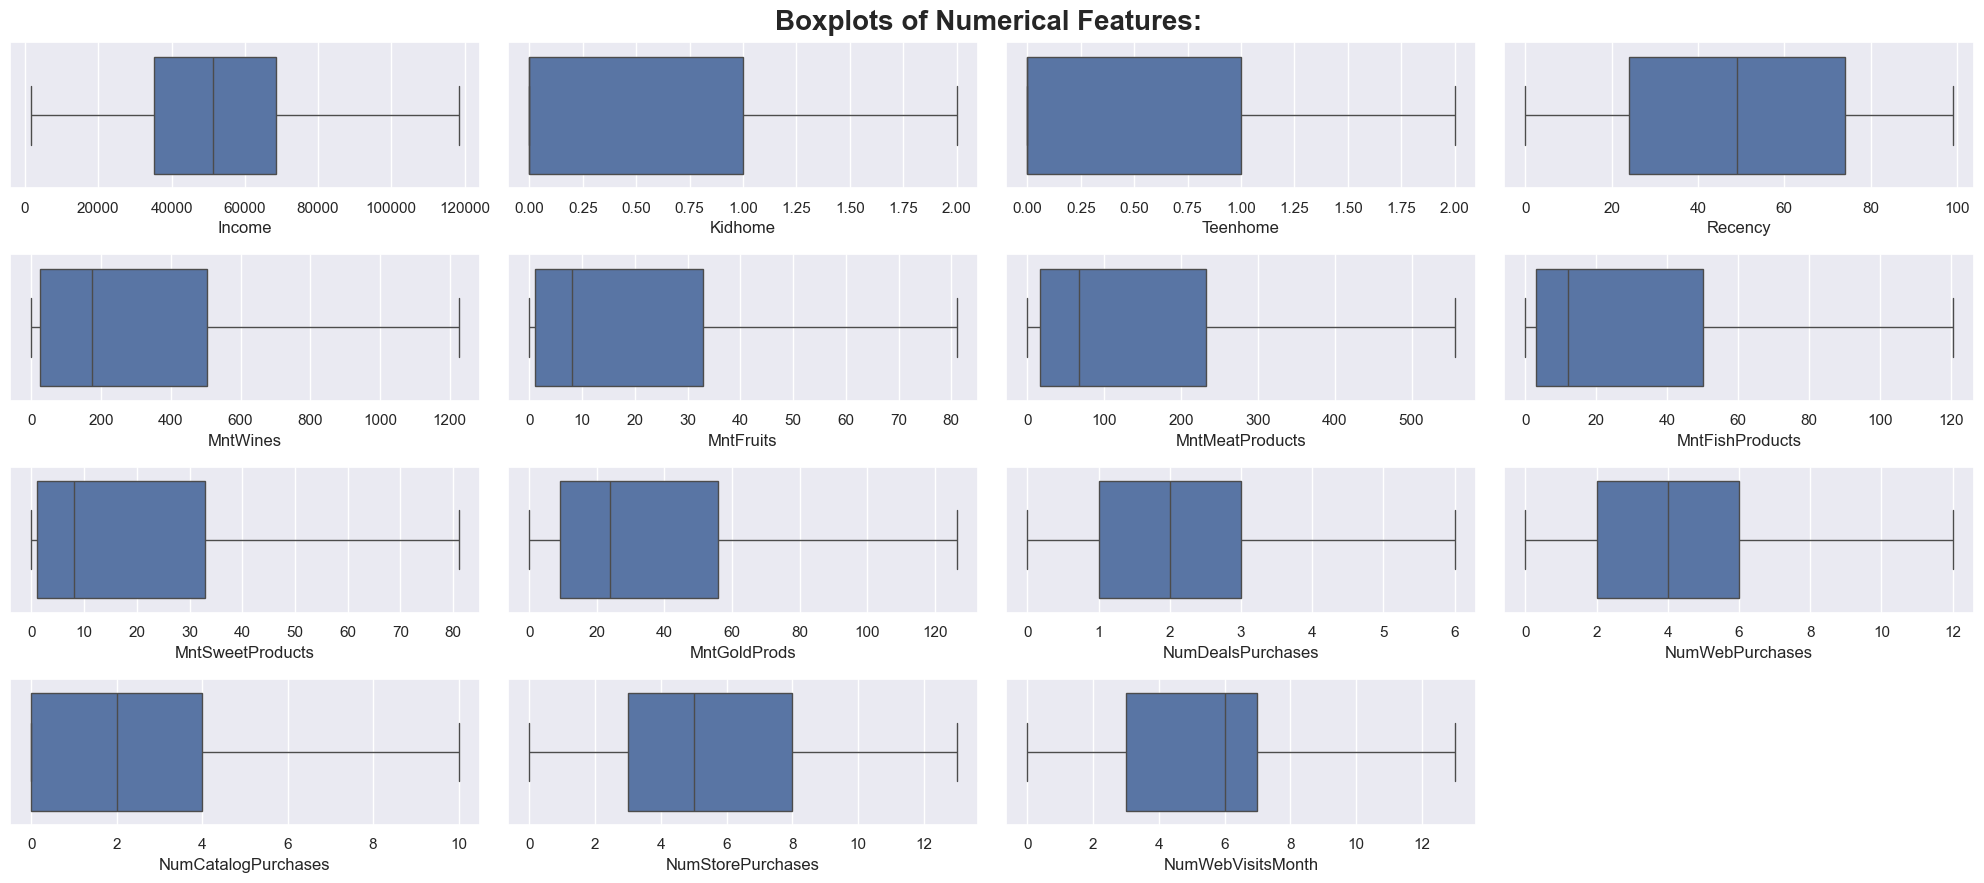

In [99]:
plt.figure(figsize=(20,15))
plt.suptitle("Boxplots of Numerical Features: ", fontsize = 20, fontweight = 'bold')

for i in range(1, len(nums)):
    plt.subplot(7,4, i)
    plt.xlabel(nums[i])
    sns.boxplot(x = df[nums[i]])
    plt.tight_layout()

plt.show()

## Null Values

In [100]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

The Income is the only feature having outliers

<Axes: xlabel='Income', ylabel='Count'>

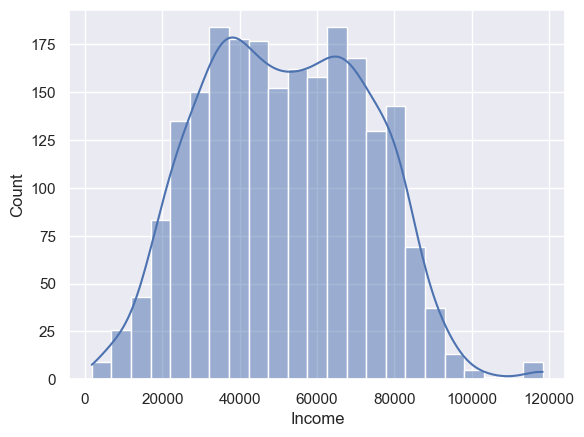

In [101]:
sns.histplot(df, x = "Income", kde = True)

***Income*** being a normally distributed data, the null values can be filled with both mean and median

In [102]:
df["Income"].fillna(df["Income"].median(), inplace = True)

C:\Users\Sukalpo Deb Nath\AppData\Local\Temp\ipykernel_28328\2612099648.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Income"].fillna(df["Income"].median(), inplace = True)


## **Feature Engineering:**

In [110]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='object')

In [ ]:
# Dropping irrelavent columns:
df.drop(["Z_CostContact", "Z_Revenue"], axis = 1, inplace = True)

In [109]:
#Catagorical Encoding
df_encoded = pd.get_dummies(df, columns = ["Education", "Marital_Status"], dtype=int)

In [111]:
df_encoded

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,1957,58138.0,0,0,04-09-2012,58,635,81,546,...,0,0,0,0,0,0,1,0,0,0
1,2174,1954,46344.0,1,1,08-03-2014,38,11,1,6,...,0,0,0,0,0,0,1,0,0,0
2,4141,1965,71613.0,0,0,21-08-2013,26,426,49,127,...,0,0,0,0,0,0,0,1,0,0
3,6182,1984,26646.0,1,0,10-02-2014,26,11,4,20,...,0,0,0,0,0,0,0,1,0,0
4,5324,1981,58293.0,1,0,19-01-2014,94,173,43,118,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,61223.0,0,1,13-06-2013,46,709,43,182,...,0,0,0,0,0,1,0,0,0,0
2236,4001,1946,64014.0,2,1,10-06-2014,56,406,0,30,...,0,1,0,0,0,0,0,1,0,0
2237,7270,1981,56981.0,0,0,25-01-2014,91,908,48,217,...,0,0,0,0,1,0,0,0,0,0
2238,8235,1956,69245.0,0,1,24-01-2014,8,428,30,214,...,1,0,0,0,0,0,0,1,0,0


In [113]:
#Adding new Features:
df_encoded["Age"] = 2014 - df["Year_Birth"]
df_encoded["Customer_Year"] = df1["Customer_Year"]
df_encoded["AvgMnt"] = (df_encoded['MntWines']+ df_encoded['MntFruits']+df_encoded['MntMeatProducts']+ df_encoded['MntFishProducts'] + df_encoded['MntSweetProducts'] + df_encoded['MntGoldProds'])/6
df_encoded["Total_Purchase"] = df_encoded['NumDealsPurchases'] + df_encoded['NumWebPurchases'] + df_encoded['NumCatalogPurchases'] +  df_encoded['NumStorePurchases']


#Deleting the least Impactful data
df_encoded.drop(["Marital_Status_Absurd", "Marital_Status_Alone", "Marital_Status_YOLO"], axis = 1, inplace=True)

In [115]:
df_encoded.drop("ID", axis = 1, inplace= True)

In [117]:
df_encoded.drop("Dt_Customer", axis = 1, inplace= True)

In [129]:
df_encoded.drop("Year_Birth", axis= 1, inplace= True)

## **Feature Scaling:**

In [123]:
print(len(df_encoded.columns))

37


In [124]:
numerical_col.extend(["Age", "Customer_Year", "AvgMnt", "Total_Purchase"])

In [136]:
numerical_col = [i for i in numerical_col if i not in ['ID', 'Z_CostContact', 'Z_Revenue', "Year_Birth", 'AcceptedCmp4', 'AcceptedCmp3'	,'AcceptedCmp5',	'AcceptedCmp1',	'AcceptedCmp2',	'Complain',	'Response']]

In [137]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
scaled = pd.DataFrame(scalar.fit_transform(df_encoded[numerical_col]), columns = numerical_col)

In [138]:
scaled

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Customer_Year,AvgMnt,Total_Purchase
0,0.299341,-0.825218,-0.929894,0.307039,1.005751,2.176816,2.210169,2.190303,2.145044,1.215280,0.509888,1.488353,2.697675,-0.550785,0.724452,1.007064,-1.502225,1.797892,1.380023
1,-0.263835,1.032559,0.906934,-0.383664,-0.879539,-0.758828,-0.810358,-0.746320,-0.760435,-0.838900,-0.140168,-1.156408,-0.594004,-1.166125,-0.127397,1.261969,1.420036,-0.989563,-1.163336
2,0.942786,-0.825218,-0.929894,-0.798086,0.374300,1.002558,-0.133536,1.954878,-0.034065,0.062935,-0.790225,1.488353,-0.228262,1.295237,-0.553322,0.327318,-0.041094,0.379937,0.844579
3,-1.204435,1.032559,-0.929894,-0.798086,-0.879539,-0.648741,-0.732048,-0.548067,-0.687798,-0.863951,-0.140168,-0.778585,-0.959746,-0.550785,0.298528,-1.287080,1.420036,-0.942024,-0.895614
4,0.306743,1.032559,-0.929894,1.550305,-0.390089,0.782385,-0.183879,0.344072,0.183846,-0.613442,1.810001,0.354884,0.137480,0.064556,-0.127397,-1.032175,1.420036,-0.267330,0.576857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,0.446653,-0.825218,0.906934,-0.107383,1.229327,0.782385,0.174110,0.244945,2.145044,2.179743,-0.140168,1.866176,0.137480,-0.550785,-0.127397,0.157381,-0.041094,1.125026,0.442996
2236,0.579926,2.890335,0.906934,0.237969,0.313874,-0.795523,-0.676113,-0.795883,-0.796753,-0.788798,2.460058,1.488353,-0.228262,-0.243114,0.724452,1.941715,1.420036,-0.227104,0.844579
2237,0.244093,-0.825218,-0.929894,1.446700,1.830566,0.965863,0.369885,-0.002871,-0.360931,-0.387983,-0.790225,-0.778585,0.137480,2.218248,0.298528,-1.032175,1.420036,1.230161,0.576857
2238,0.829712,-0.825218,0.906934,-1.419719,0.380342,0.305343,0.353104,1.186647,0.292802,0.538904,-0.140168,0.732707,0.868964,1.295237,-0.979246,1.092032,1.420036,0.502443,1.112301


In [139]:
df_scaled = df_encoded.copy()

In [140]:
df_scaled[numerical_col] = scaled

In [145]:
df_scaled

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Age,Customer_Year,AvgMnt,Total_Purchase
0,0.299341,-0.825218,-0.929894,0.307039,1.005751,2.176816,2.210169,2.190303,2.145044,1.215280,0.509888,1.488353,2.697675,-0.550785,0.724452,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1.007064,-1.502225,1.797892,1.380023
1,-0.263835,1.032559,0.906934,-0.383664,-0.879539,-0.758828,-0.810358,-0.746320,-0.760435,-0.838900,-0.140168,-1.156408,-0.594004,-1.166125,-0.127397,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1.261969,1.420036,-0.989563,-1.163336
2,0.942786,-0.825218,-0.929894,-0.798086,0.374300,1.002558,-0.133536,1.954878,-0.034065,0.062935,-0.790225,1.488353,-0.228262,1.295237,-0.553322,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0.327318,-0.041094,0.379937,0.844579
3,-1.204435,1.032559,-0.929894,-0.798086,-0.879539,-0.648741,-0.732048,-0.548067,-0.687798,-0.863951,-0.140168,-0.778585,-0.959746,-0.550785,0.298528,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,-1.287080,1.420036,-0.942024,-0.895614
4,0.306743,1.032559,-0.929894,1.550305,-0.390089,0.782385,-0.183879,0.344072,0.183846,-0.613442,1.810001,0.354884,0.137480,0.064556,-0.127397,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,-1.032175,1.420036,-0.267330,0.576857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,0.446653,-0.825218,0.906934,-0.107383,1.229327,0.782385,0.174110,0.244945,2.145044,2.179743,-0.140168,1.866176,0.137480,-0.550785,-0.127397,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0.157381,-0.041094,1.125026,0.442996
2236,0.579926,2.890335,0.906934,0.237969,0.313874,-0.795523,-0.676113,-0.795883,-0.796753,-0.788798,2.460058,1.488353,-0.228262,-0.243114,0.724452,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1.941715,1.420036,-0.227104,0.844579
2237,0.244093,-0.825218,-0.929894,1.446700,1.830566,0.965863,0.369885,-0.002871,-0.360931,-0.387983,-0.790225,-0.778585,0.137480,2.218248,0.298528,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,-1.032175,1.420036,1.230161,0.576857
2238,0.829712,-0.825218,0.906934,-1.419719,0.380342,0.305343,0.353104,1.186647,0.292802,0.538904,-0.140168,0.732707,0.868964,1.295237,-0.979246,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1.092032,1.420036,0.502443,1.112301


## **Model Training:**

## K-Means:

In [173]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

**Checking The PCA values:**

In [171]:
for pc in range(2, 8):
    print(f"Setting PCA to {pc}: ")
    for k in range(2,6):
        pca = PCA(n_components=pc)
        df_reduced = pca.fit_transform(df_scaled)
        model = KMeans(n_clusters=k)
        label = model.fit_predict(df_reduced)
        score = silhouette_score(df_reduced, label)
        print(f"            Silhouette score of {k} Clusters = {score}")

Setting PCA to 2: 
            Silhouette score of 2 Clusters = 0.5546521633578844
            Silhouette score of 3 Clusters = 0.5320210992328087
            Silhouette score of 4 Clusters = 0.47578435992853535
            Silhouette score of 5 Clusters = 0.4822970309995735
Setting PCA to 3: 
            Silhouette score of 2 Clusters = 0.48306264657273124
            Silhouette score of 3 Clusters = 0.4322686067118801
            Silhouette score of 4 Clusters = 0.36104033643839567
            Silhouette score of 5 Clusters = 0.3296739989198689
Setting PCA to 4: 
            Silhouette score of 2 Clusters = 0.4427803542148501
            Silhouette score of 3 Clusters = 0.37978375191443303
            Silhouette score of 4 Clusters = 0.2905110468930774
            Silhouette score of 5 Clusters = 0.2334779090160403
Setting PCA to 5: 
            Silhouette score of 2 Clusters = 0.4147988280651274
            Silhouette score of 3 Clusters = 0.346317436184496
            Silhouette sc

* Its is evident that pca = 2 gives the best results

Plotting The Clusters of K-Means:

<Axes: xlabel='PC1', ylabel='PC2'>

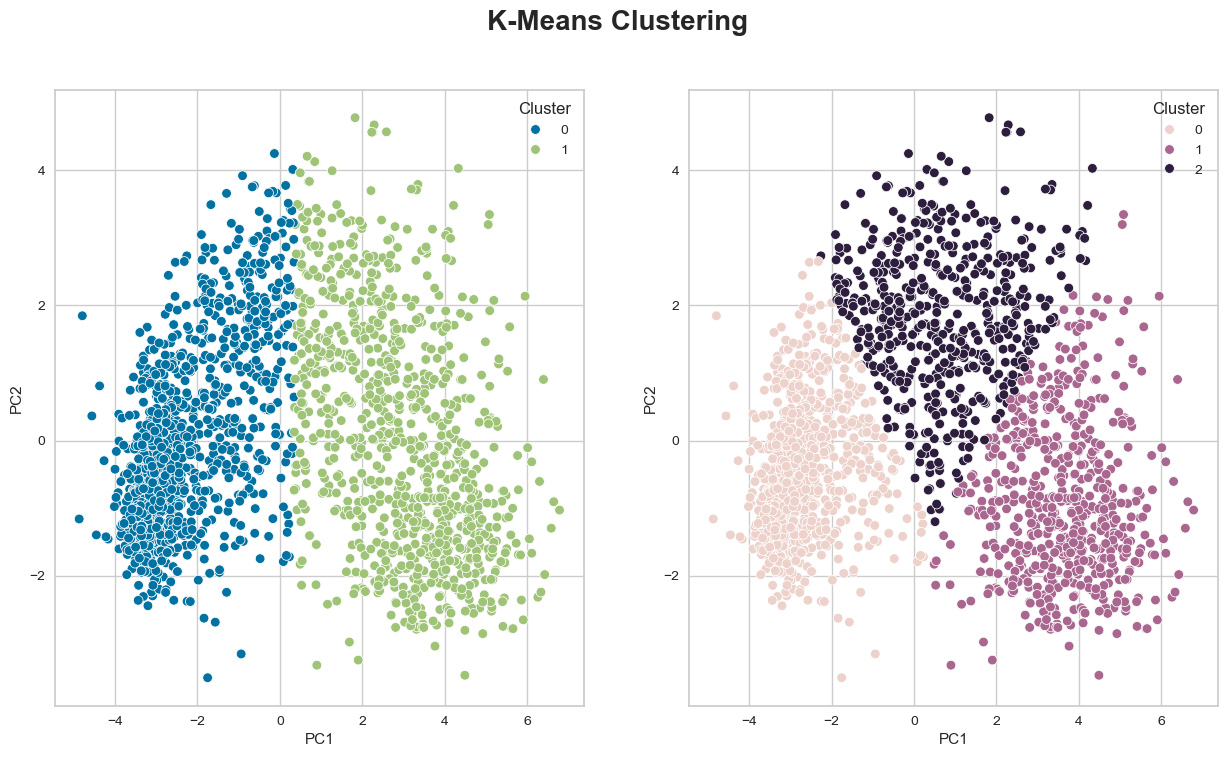

In [185]:
plt.figure(figsize = (15,8))
plt.suptitle("K-Means Clustering", fontsize = 20, fontweight = 'bold')
plt.subplot(1,2,1)
pca_2 = PCA(n_components=2)
reduced_2 = pca_2.fit_transform(df_scaled)
model_2 = KMeans(n_clusters=2)
label_2 = model_2.fit_predict(reduced_2)
reduced_2 = pd.DataFrame(reduced_2, columns = ["PC1", "PC2"])
reduced_2["Cluster"] = label_2
sns.scatterplot(reduced_2, x = "PC1", y = "PC2", hue = "Cluster")

plt.subplot(1,2,2)
pca_2 = PCA(n_components=2)
reduced_3 = pca_2.fit_transform(df_scaled)
model_3 = KMeans(n_clusters=3)
label_3 = model_3.fit_predict(reduced_3)
reduced_3 = pd.DataFrame(reduced_3, columns = ["PC1", "PC2"])
reduced_3["Cluster"] = label_3
sns.scatterplot(reduced_3, x = "PC1", y = "PC2", hue = "Cluster")


**Checking for the number of clusters:**

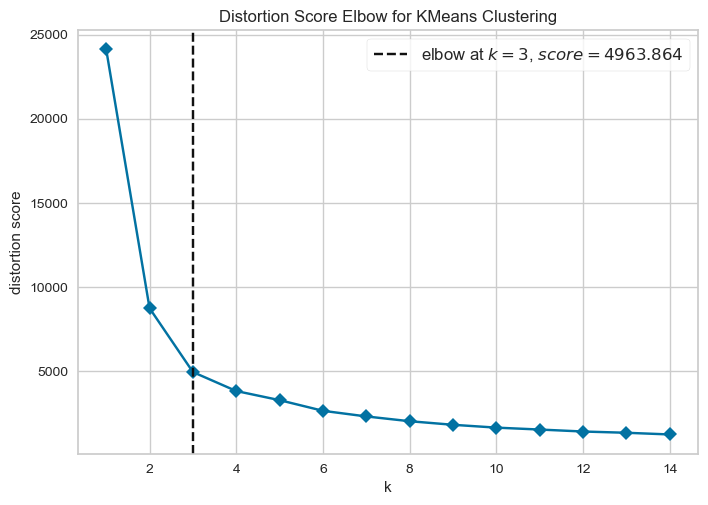

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [172]:
from yellowbrick.cluster import KElbowVisualizer
visualizer = KElbowVisualizer(KMeans(), k = (1,15), timings= False)
pca2 = PCA(n_components=2)
visualizer.fit(pca2.fit_transform(df_scaled))
visualizer.show()

**The K means model gave silhouette score of 0.5546521633578844**

## Hierarchical Clustering: 

In [174]:
from sklearn.cluster import AgglomerativeClustering

In [175]:
for pc in range(2, 6):
    print(f"Setting PCA to {pc}: ")
    for k in range(2,6):
        pca = PCA(n_components=pc)
        df_reduced = pca.fit_transform(df_scaled)
        model = AgglomerativeClustering(n_clusters=k)
        label = model.fit_predict(df_reduced)
        score = silhouette_score(df_reduced, label)
        print(f"            Silhouette score of {k} Clusters = {score}")

Setting PCA to 2: 
            Silhouette score of 2 Clusters = 0.5084715186279829
            Silhouette score of 3 Clusters = 0.4847159018763383
            Silhouette score of 4 Clusters = 0.4507244340711521
            Silhouette score of 5 Clusters = 0.3752603168151901
Setting PCA to 3: 
            Silhouette score of 2 Clusters = 0.47367936400362587
            Silhouette score of 3 Clusters = 0.3696774623566462
            Silhouette score of 4 Clusters = 0.33567006013928735
            Silhouette score of 5 Clusters = 0.28386473894958164
Setting PCA to 4: 
            Silhouette score of 2 Clusters = 0.40678026147176005
            Silhouette score of 3 Clusters = 0.36100299768264543
            Silhouette score of 4 Clusters = 0.24558725415886334
            Silhouette score of 5 Clusters = 0.2182559373235616
Setting PCA to 5: 
            Silhouette score of 2 Clusters = 0.3722649472917654
            Silhouette score of 3 Clusters = 0.32235731158270886
            Silhouett

* The silhouette score for Hierarchical Clustering is for PCA = 2 and K = 2 : 0.5084715186279829

Plotting the clusters of Agglomerative Clustering:

<Axes: xlabel='PC1', ylabel='PC2'>

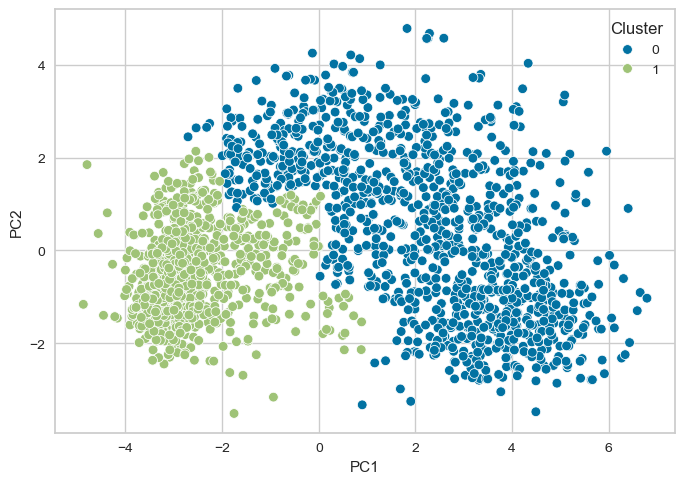

In [186]:
reduced_tree = pca_2.fit_transform(df_scaled)
model_tree = AgglomerativeClustering(n_clusters=2)
label_tree = model_tree.fit_predict(reduced_tree)
reduced_tree = pd.DataFrame(reduced_tree, columns = ["PC1", "PC2"])
reduced_tree["Cluster"] = label_tree
sns.scatterplot(reduced_tree, x = "PC1", y = "PC2", hue = "Cluster")

In [176]:
from sklearn.cluster import DBSCAN

In [181]:
best_score = -1
for pc in range(2, 6):
    for e in [0.1, 0.2, 0.4, 0.5, 0.8]:
        for n in range(2, 9):
            pca = PCA(n_components=pc)
            df_reduced = pca.fit_transform(df_scaled)
            model = DBSCAN(eps = e, min_samples=n )
            label = model.fit_predict(df_reduced)
            try:
                score = silhouette_score(df_reduced, label)
                best_score = max(best_score, score)
            except:
                continue

print(best_score)

0.27878501242922693


* The silhouette score for DBSCAN is 0.27878501242922693

## **Report:**

* Overall The K-Means Clustering Model gave the highest silhouette score (0.5546521633578844) followed by Agglomerative Clustering model (0.5084715186279829).
* Whereas The DBSCAN algorithm worked poorly than the previous models with a silhouette score of 0.27878501242922693

## **Decision:**

* With PCA = 2 and Number of Clusters = 2 The K-Means Clustering provided the best results on this dataset.
* So our selected model will be K-Means (with PCA = 2 and n_clusters = 2)

In [187]:
df_encoded["Cluster"] = reduced_2["Cluster"]

In [188]:
df_encoded

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Age,Customer_Year,AvgMnt,Total_Purchase,Cluster
0,58138.0,0,0,58,635,81,546,120.5,81,88.0,3,8,10,4,7,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,57,2012,258.583333,25,1
1,46344.0,1,1,38,11,1,6,2.0,1,6.0,2,1,1,2,5,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,60,2014,4.500000,6,0
2,71613.0,0,0,26,426,49,127,111.0,21,42.0,1,8,2,10,4,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,49,2013,129.333333,21,1
3,26646.0,1,0,26,11,4,20,10.0,3,5.0,2,2,0,4,6,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,30,2014,8.833333,8,0
4,58293.0,1,0,94,173,43,118,46.0,27,15.0,5,5,3,6,5,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,33,2014,70.333333,19,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,0,1,46,709,43,182,42.0,81,126.5,2,9,3,4,5,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,47,2013,197.250000,18,1
2236,64014.0,2,1,56,406,0,30,0.0,0,8.0,6,8,2,5,7,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,68,2014,74.000000,21,0
2237,56981.0,0,0,91,908,48,217,32.0,12,24.0,1,2,3,13,6,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,33,2014,206.833333,19,1
2238,69245.0,0,1,8,428,30,214,80.0,30,61.0,2,6,5,10,3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,58,2014,140.500000,23,1


In [189]:
df_encoded.groupby("Cluster").mean()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Age,Customer_Year,AvgMnt,Total_Purchase
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,37685.298655,0.718354,0.537184,48.700949,82.980222,5.561709,32.534019,8.382120,5.609968,20.270965,2.354430,2.773734,0.780063,3.667722,6.397943,0.066456,0.033228,0.000000,0.005538,0.003165,0.011076,0.097310,0.096519,0.041139,0.489715,0.175633,0.196994,0.099684,0.390823,0.218354,0.261867,0.025316,43.672468,2013.083861,25.889834,9.575949
1,70238.540471,0.089139,0.466189,49.638320,585.907787,42.552254,304.132172,62.852971,43.084016,64.375000,2.035861,5.727459,5.012295,8.538934,3.876025,0.080943,0.128074,0.167008,0.140369,0.026639,0.007172,0.216189,0.082992,0.002049,0.520492,0.151639,0.242828,0.108607,0.379098,0.209016,0.255123,0.046107,47.058402,2012.955943,183.817367,21.314549


In [190]:
df_encoded.groupby("Cluster").sum()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Age,Customer_Year,AvgMnt,Total_Purchase
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,47634217.5,908,679,61558,104887,7030,41123,10595.0,7091,25622.5,2976,3506,986,4636,8087,84,42,0,7,4,14,123,122,52,619,222,249,126,494,276,331,32,55202,2544538,32724.75,12104
1,68552815.5,87,455,48447,571846,41531,296833,61344.5,42050,62830.0,1987,5590,4892,8334,3783,79,125,163,137,26,7,211,81,2,508,148,237,106,370,204,249,45,45929,1964645,179405.75,20803


## **Cluster Profiling:**

* Cluster- 0: 
    - Less Income
    - High number of children
    - Less amount of spendings and less number of purchase
    - Higher in deal purchase
    - Less Purchase but Higher Visits
    - Not very much interested in campaigns

* Cluster- 1:
    - High Income
    - Less number of children
    - High amount of spendings and high number of purchase
    - Almost similar but little less in deal purchase
    - High Purchase and less Visits
    - Not very much interested in campaigns either but higher than cluster 0


## **Insights:**

* Cluster-0:
    - Budget Customers
    - More interested in deals for product purchase

* Cluster - 1:
    - Premimum Customers 
    - Heavy Purchase and Least Visitors